# Bounding Parameters
- want to find the maximum number of endpoints
- given the maximum computation time (time for vanilla rainbow table)


In [69]:
from scipy.optimize import minimize, Bounds
from math import pi, sqrt
from statistics import NormalDist
from math import e, log
import matplotlib.pyplot as plt

In [70]:
# parameters
N = 2**20 # Declare the problem size
p = 1-e**-2 # our table coverage
t = round(log(1-p)/log(1-N**(-1/3))) # Calculate t

max_cost = 6403673  # cost of vanilla rainbow table from dissertation
max_kj_value = 10000 # maximum number of searches

### Cost Function

In [71]:
# Title: Chapter 5 Experiments
# Author: Steven Kurniawan Chandra
# Date: September 2023
# Type: Source Code

## Change the cost function to only calculate cost, as this is now a constraint
    # only change is not returning the square root of the cost
def cost(inputs): 
    ### the input variables to find are as follows:
    # input[0] is the number of starting points
    # input[1:] is the K_j for all 1<=j<=t
    
    m = inputs[0] # number of starting points
    K_js = inputs[1:] # K_j values
    cost = 0 # cost counter
    
    for k in K_js: # iterate through the column
        # Calculate E1 and E2 - probabilities to calculate average and variance
        E1 = (1-1/N)**m
        E2 = (1-2/N)**m
        # calculate the statistical average of m_j+1
        average = N*(1 - E1)
        ## check if the variance is positive, sometimes error happens because of float calculation on very small values
        
        if N*((N-1)*E2 + E1 - N*E1**2)<0:
            # if it is negative (error), set it to 0
            variance = 0
        else:
            # count the variance otherwise
            variance = sqrt(N*((N-1)*E2 + E1 - N*E1**2))
            
        # count the cost before defining the new m
        cost += m + m * k/577.44
        # find the m_j+1
        m = average + NormalDist().inv_cdf((k-pi/8)/(k-pi/4+1))*variance
        
    return cost # return the cost

In [72]:
# alter m_t to get -m_t to maximise - out objective function
def m_t(inputs):
    ### the input variables to find are as follows:
    # input[0] is the number of starting points
    # input[1:] is the K_j for all 1<=j<=t
    
    m = inputs[0] # number of starting points
    K_js = inputs[1:] # K_j values
    target = N**(2/3) ## our target m_t
    
    for k in K_js:# iterate through the column
        # Calculate E1 and E2
        E1 = (1-1/N)**m
        E2 = (1-2/N)**m
        # calculate the statistical average of m_j+1
        average = N*(1 - E1)
        # check if the variance is positive, sometimes error happens because of float calculation on very small values
        if N*((N-1)*E2 + E1 - N*E1**2)<0:
            # if it is negative (error), set it to 0
            variance = 0
        else:
            # count the statistical variance of m_j+1 otherwise
            variance = sqrt(N*((N-1)*E2 + E1 - N*E1**2))
        # find the m_j+1
        m = average +  NormalDist().inv_cdf((k-pi/8)/(k-pi/4+1))*variance
    return -m # return -m to maximise endpoints


In [73]:
# set up optimisation problem

# Define bounds and constraints
# bounds for decision variable - kj for each column
    # lower bound is at least 1, upper bound set to 10 000
bounds = Bounds([1 for i in range(t+1)], [max_kj_value for i in range(t+1)]) # m_0 >= 1 and each K_j <= max_kj_value
# bounds = Bounds([1 for i in range(t+1)], [float("inf") for j in range(t+1)])  
constraints = [
    {'type': 'ineq', 'fun': lambda x: max_cost - cost(x)},  # Make sure cost is <= max_cost
]

## use 1 as starting values
starting_values = [1 for k in range(round(t+1))]

# optimiser
result = minimize(
    m_t,  # objective function to maximize endpoints
    starting_values,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={'disp': True, 'maxiter': 5000000, 'eps': 0.5}
)

## Extract results
m_0 = round(result.x[0])  # Optimized number of starting points
K_js = result.x[1:]  # Optimized K_j values for each column

Optimization terminated successfully    (Exit mode 0)
            Current function value: -7141.085277380722
            Iterations: 71
            Function evaluations: 14552
            Gradient evaluations: 71


Text(0.5, 1.0, 'Number of index searches ($K_{j}$) per column (j) with bounded precomputation cost P=6 403 673 and bounded $K_{j}$ = 10 000')

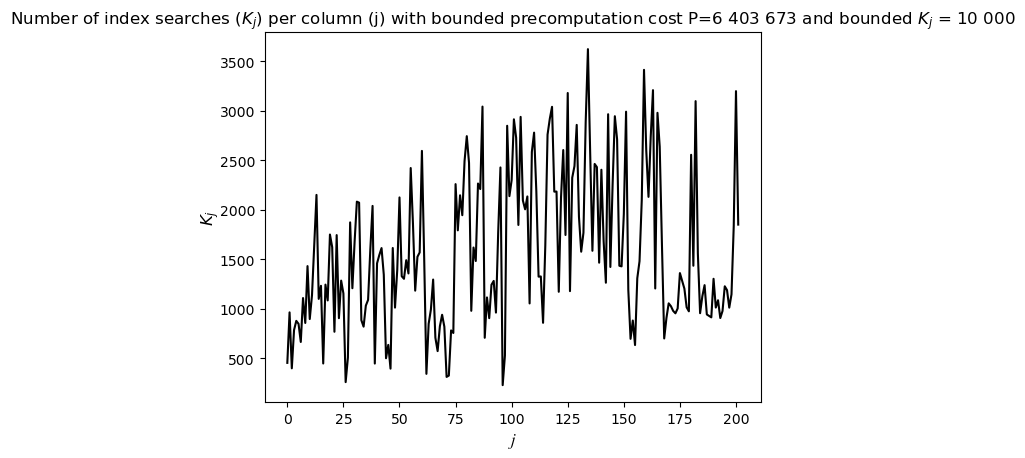

In [74]:
# plot figure
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(K_js, "k", label = "K")
ax.set_ylabel(r"$K_{j}$", **{"fontname": "Times New Roman", "style":"italic", "fontsize":12, "labelpad":-2})
ax.set_xlabel("j", **{"fontname": "Times New Roman", "style":"italic", "fontsize":12})
ax.set_title("Number of index searches ($K_{j}$) per column (j) with bounded precomputation cost P=6 403 673 and bounded $K_{j}$ = 10 000")